In [1]:
# Importing the common file
from common import *

# Importing the classifiers
from sklearn.tree import plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier as KNN

# Initializing results dict
results = {}

## Classifier-Specific Helper Functions

In [2]:
def plot_decision_tree(model, feature_names, class_names, scaled, path, max_depth_display=3):
    """
    Visualizes a part of the decision tree
    """

    plt.figure(figsize=(16, 16))
    plot_tree(model, feature_names=feature_names, class_names=class_names, filled=True, max_depth=max_depth_display, fontsize=8)
    plt.title(f"Decision Tree Structure ({scaled.capitalize()})")
    plt.tight_layout()

    full_path = common_path / path
    os.makedirs(full_path.parent, exist_ok=True)
    plt.savefig(full_path, dpi=200, bbox_inches="tight")

    plt.show()

In [3]:
def plot_sweep(results: dict, param_name, title, path):
    """
    Plots the sweep of different k values or depths
    """

    values = list(results.keys())
    train_acc = [results[v]['Training Accuracy'] for v in values]
    test_acc = [results[v]["Testing Accuracy"] for v in values]

    plt.figure(figsize=(8,8))
    plt.plot(values, train_acc, label="Training Accuracy")
    plt.plot(values, test_acc, label="Testing Accuracy")

    plt.xlabel(param_name)
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    full_path = common_path / path
    os.makedirs(full_path.parent, exist_ok=True)
    plt.savefig(full_path, dpi=200, bbox_inches="tight")

    plt.show()

## Naive-Bayes Classifier

In [4]:
def run_nb():
    out_path = common_path / "naive_bayes"
    os.makedirs(out_path, exist_ok=True)

    train_x, test_x, train_y, test_y, class_names, _ = data_preprocess(scaler=True)

    print("\n")
    print("=" * 60)
    print("Naive Bayes Classifier Trained on Breast Cancer Dataset")
    print("=" * 60)
    
    _, predicted_Y, metrics = train_and_eval_model(GaussianNB(), train_x, test_x, train_y, test_y)
    results["Naive Bayes"] = metrics
    
    plot_cm(test_y, predicted_Y, class_names, title="Naive Bayes Classifier", path=out_path / "confusion_matrix")

## Decision Tree Classifier

In [5]:
def run_dt():
    out_path = common_path / "decision_tree"
    os.makedirs(out_path, exist_ok=True)
    
    depths = [1, 2, 3, 5, 10, None]

    for scaled in [True, False]:
        scale_tag = "scaled" if scaled else "unscaled"
        label = f"Decision Tree ({scale_tag.capitalize()})"

        train_x, test_x, train_y, test_y, class_names, feature_names = data_preprocess(scaler=scaled)
        
        print("\n")
        print("=" * 80)
        print(f"{label} Classifier Trained on Breast Cancer Dataset")
        print("=" * 80)

        _, predicted_Y, metrics = train_and_eval_model(DecisionTreeClassifier(random_state=42), train_x, test_x, train_y, test_y)
        results[label] = metrics

        plot_cm(test_y, predicted_Y, class_names, title=label, path=out_path / f"confusion_matrix_{scale_tag}")

        depth_results = {}
        for d in depths:
            _, _, metrics_d = train_and_eval_model(DecisionTreeClassifier(max_depth=d, random_state=42),
                                                                     train_x, test_x, train_y, test_y)
            depth_results[d] = metrics_d

        plot_sweep(results=depth_results, param_name="Max Depth", title=f"{label}: Depth Sweep", path= out_path / f"depth_sweep_{scale_tag}")

        # Visualizing model for question 5
        model_5 = DecisionTreeClassifier(max_depth=3, random_state=42)
        model_5.fit(train_x, train_y)
        plot_decision_tree(model=model_5, feature_names=feature_names, class_names=class_names, scaled=scale_tag, path=out_path / f"tree_structure_{scale_tag}")

## K-Nearest Neighbor Classifier

In [6]:
def run_knn():
    out_path = common_path / "knn"
    os.makedirs(out_path, exist_ok=True)
    
    k_values = [1, 3, 5, 7, 11, 15, 21, 23]

    for scaled in [True, False]:
        scale_tag = "scaled" if scaled else "unscaled"
        label = f"KNN ({scale_tag.capitalize()})"

        train_x, test_x, train_y, test_y, class_names, feature_names = data_preprocess(scaler=scaled)

        print("\n")        
        print("=" * 80)
        print(f"{label} Classifier Trained on Breast Cancer Dataset")
        print("=" * 80)

        _, predicted_Y, metrics = train_and_eval_model(KNN(n_neighbors=5), train_x, test_x, train_y, test_y)
        results[label] = metrics
        
        plot_cm(test_y, predicted_Y, class_names, title=label, path=out_path / f"confusion_matrix_{scale_tag}")

        k_results = {}
        for k in k_values:
            _, _, metrics_k = train_and_eval_model(KNN(n_neighbors=k), train_x, test_x, train_y, test_y)
            k_results[k] = metrics_k
        
        plot_sweep(results=k_results, param_name="K", title=f"{label}: K Sweep", path=out_path / f"k_sweep_{scale_tag}")



Naive Bayes Classifier Trained on Breast Cancer Dataset


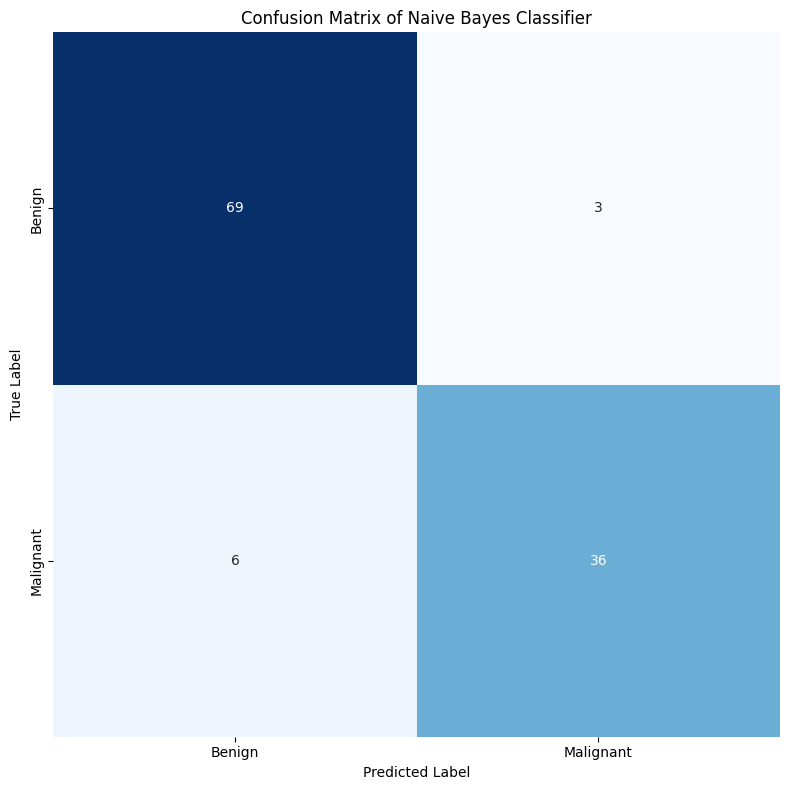



Decision Tree (Scaled) Classifier Trained on Breast Cancer Dataset


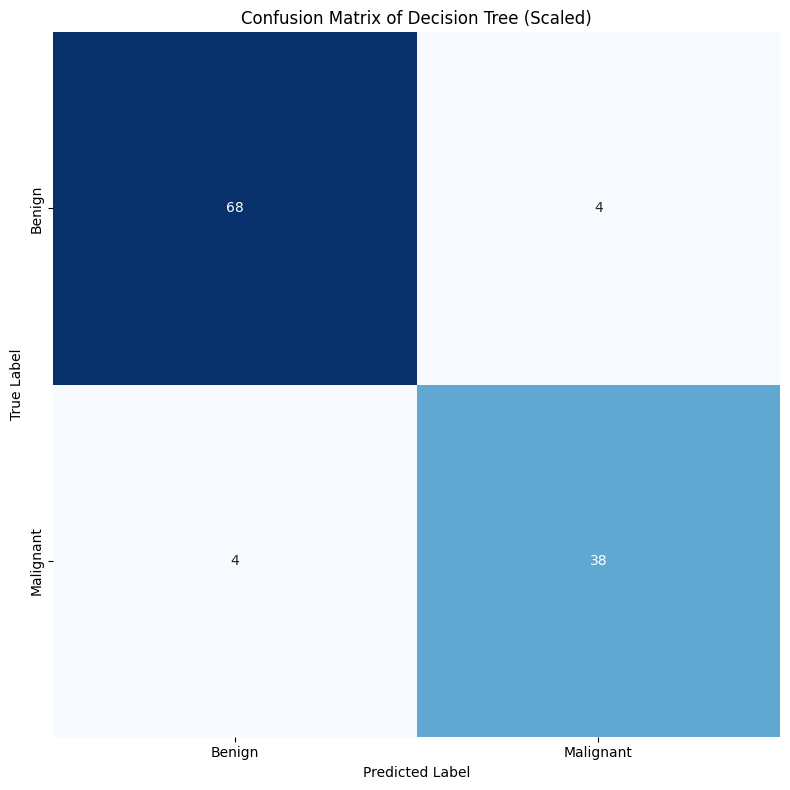

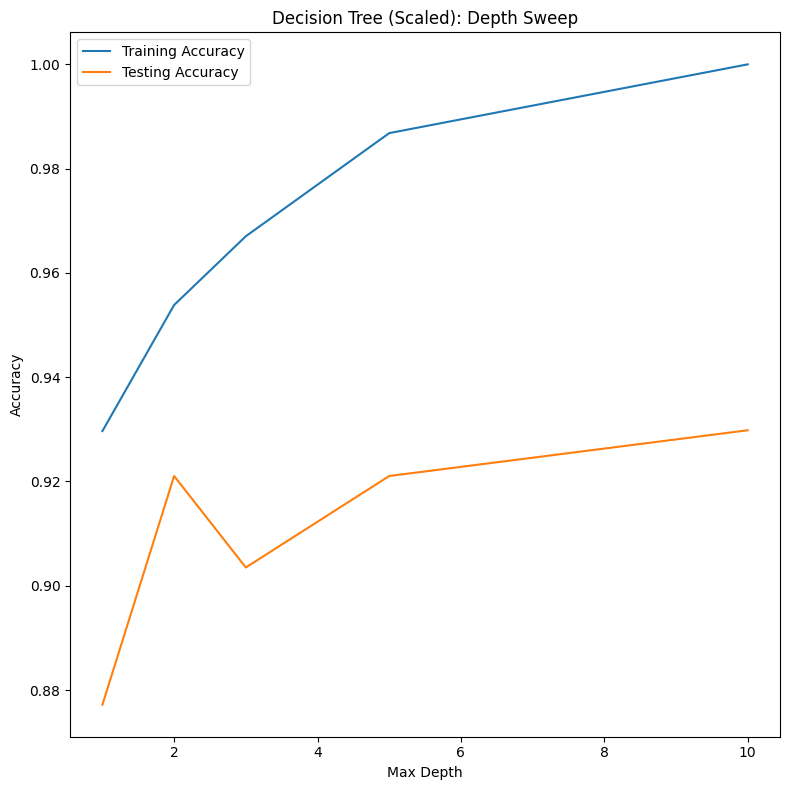

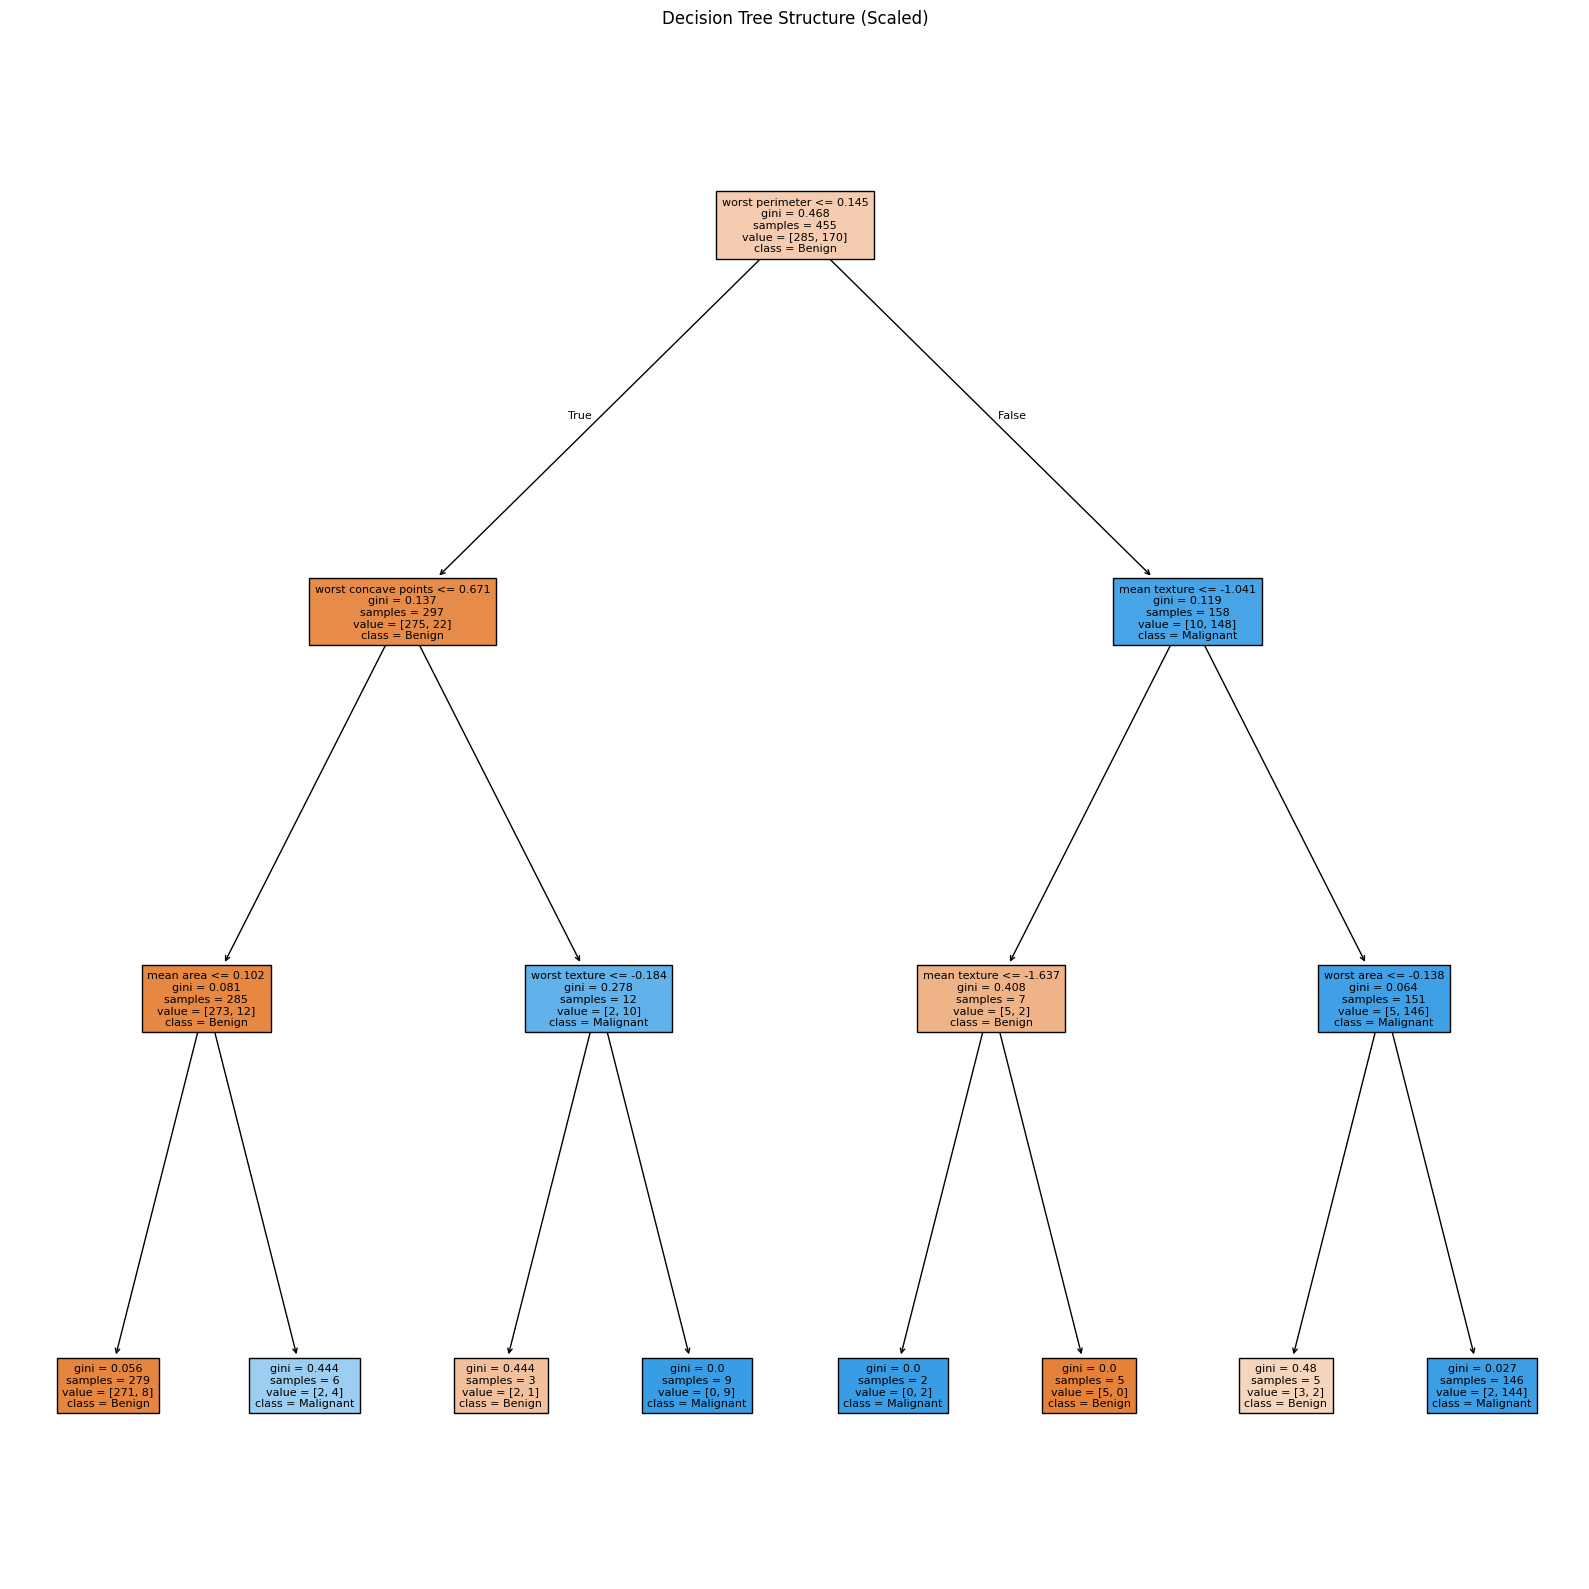



Decision Tree (Unscaled) Classifier Trained on Breast Cancer Dataset


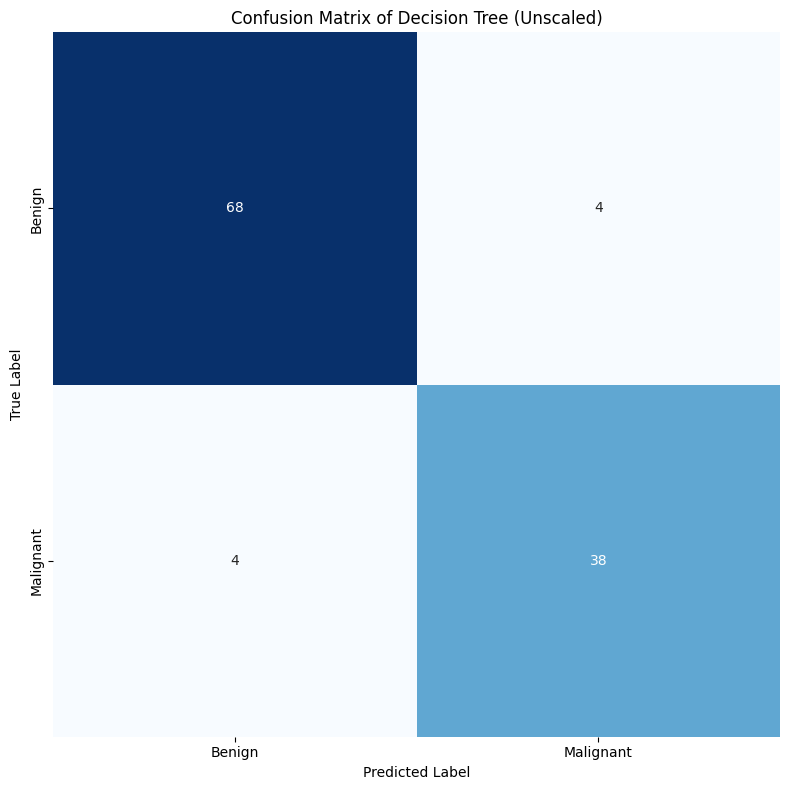

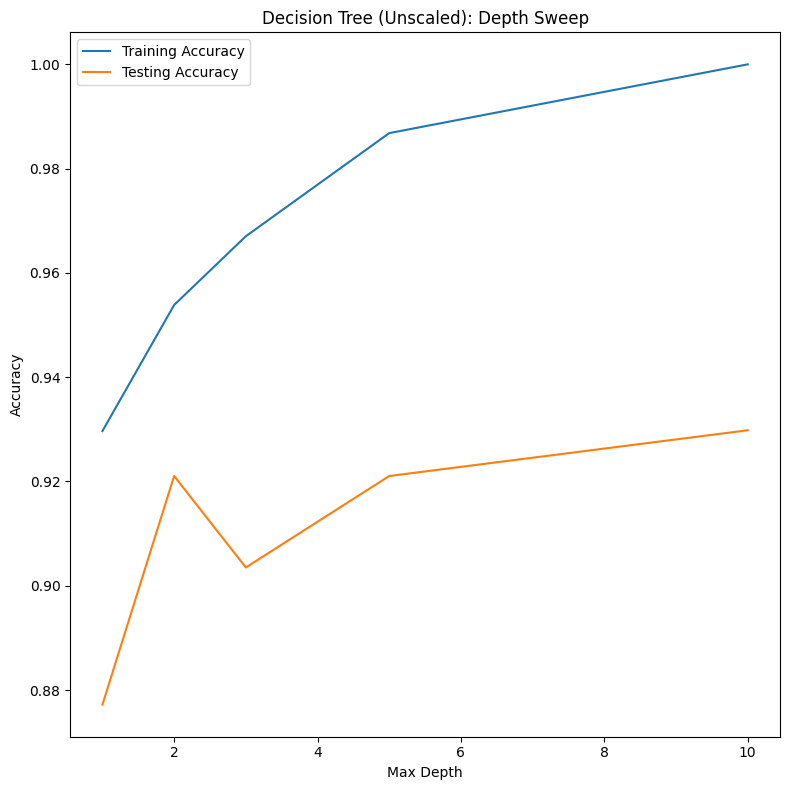

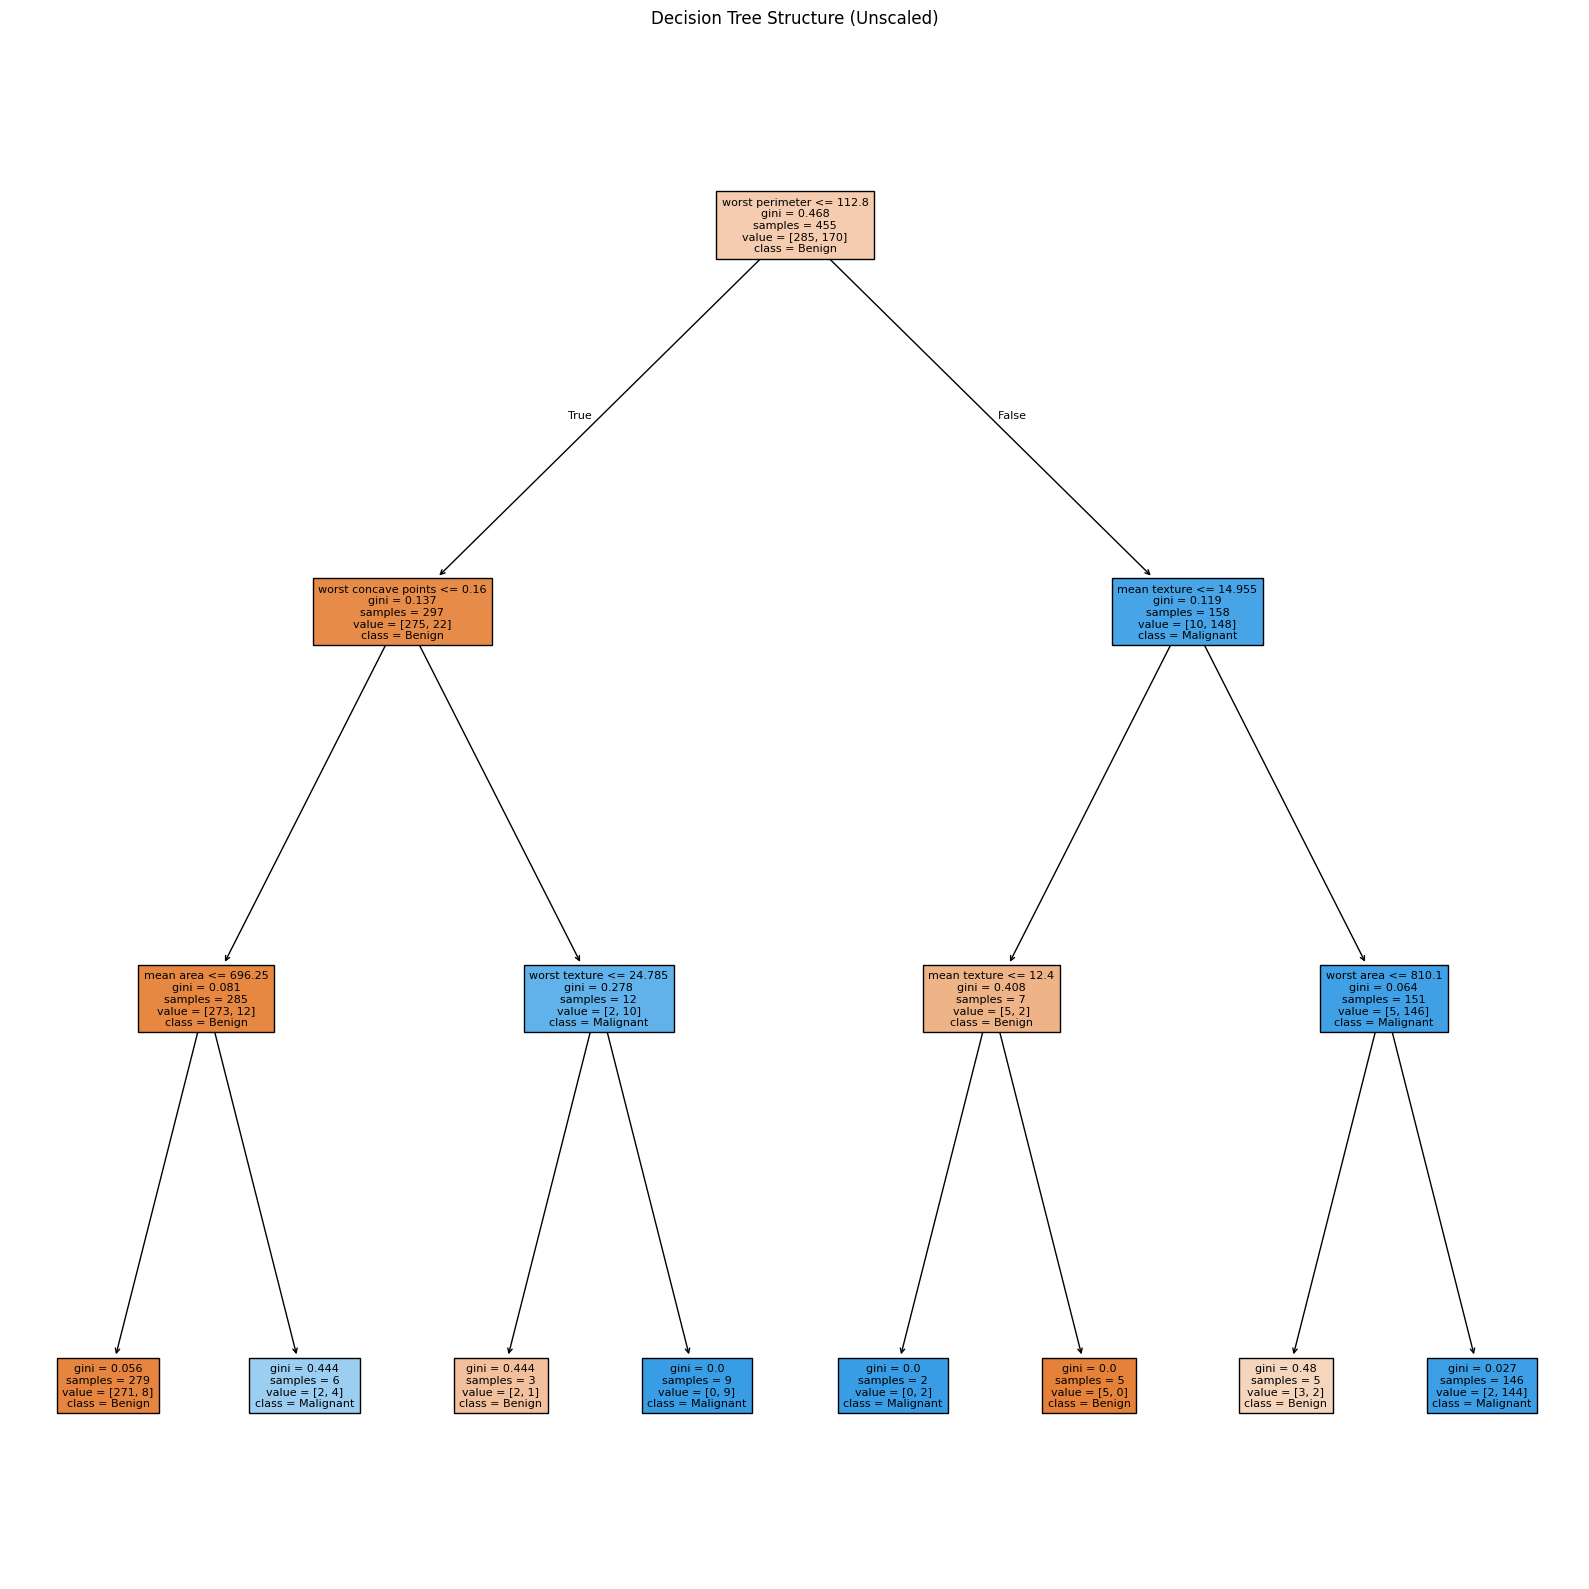



KNN (Scaled) Classifier Trained on Breast Cancer Dataset


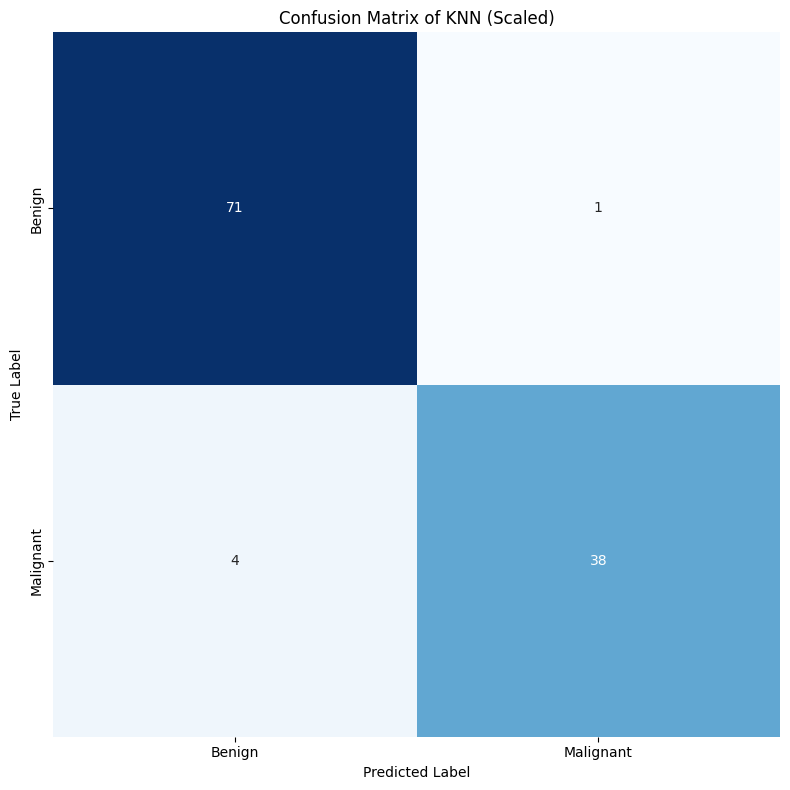

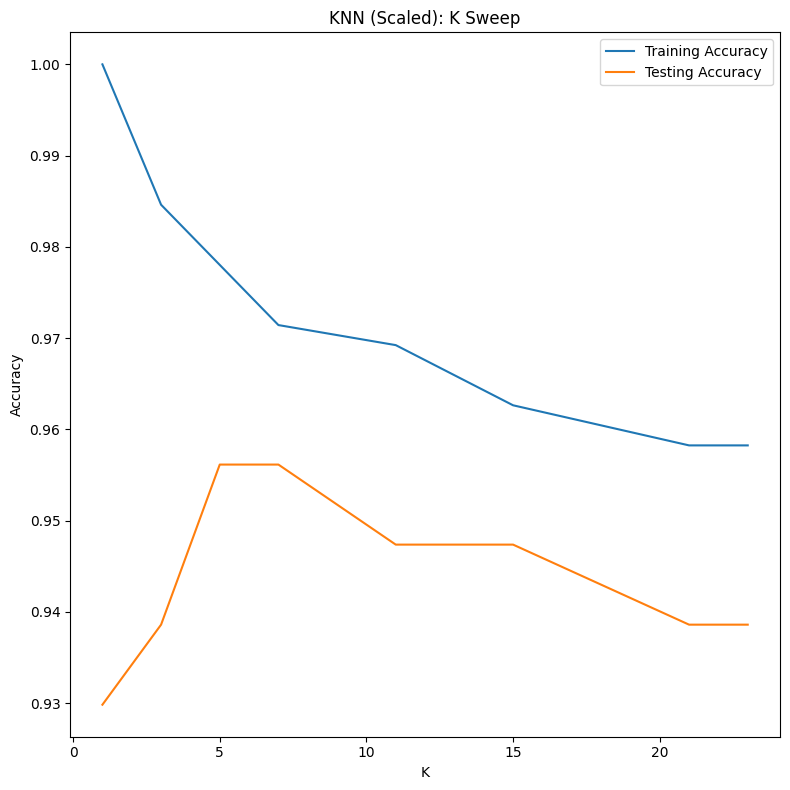



KNN (Unscaled) Classifier Trained on Breast Cancer Dataset


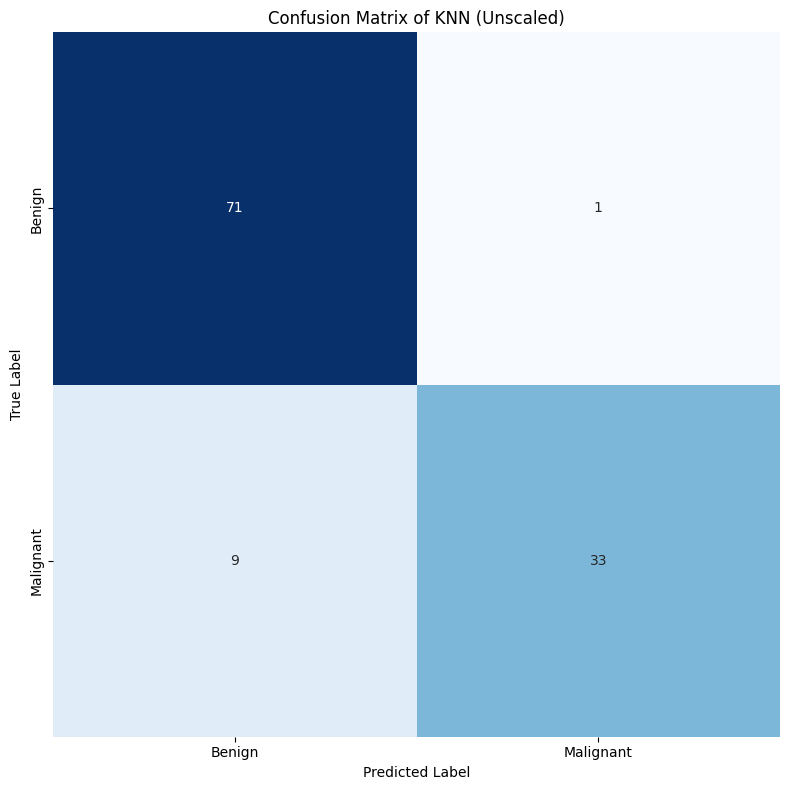

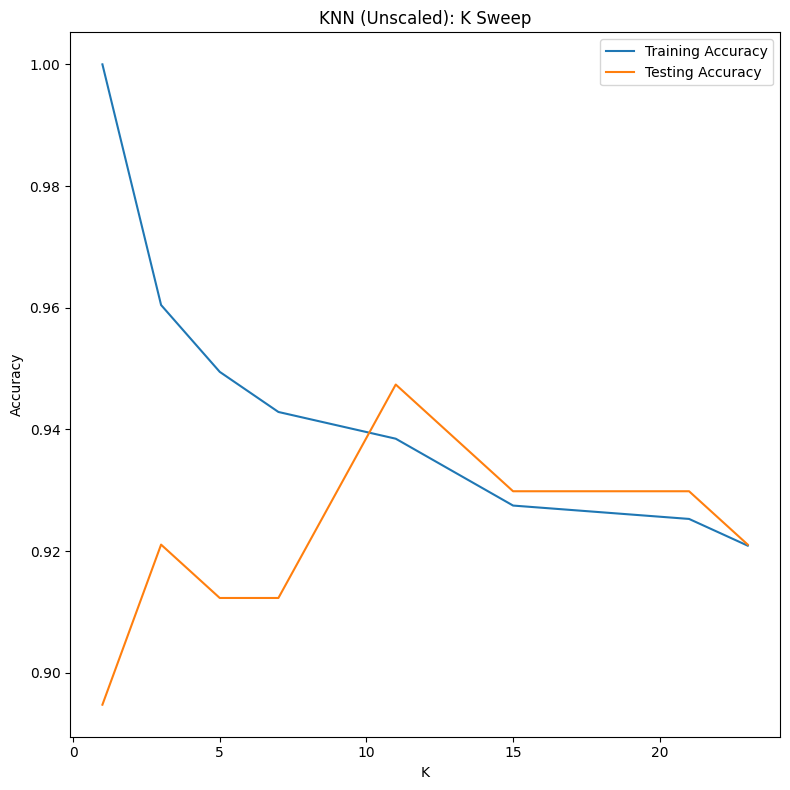



Model Metrics Results


Naive Bayes
----------------------------------------------------------------------
Training Accuracy:    0.9451
Testing Accuracy:    0.9211
Model Precision:    0.9231
Model Recall:    0.8571
F1 Score  :    0.8889


Decision Tree (Scaled)
----------------------------------------------------------------------
Training Accuracy:    1.0000
Testing Accuracy:    0.9298
Model Precision:    0.9048
Model Recall:    0.9048
F1 Score  :    0.9048


Decision Tree (Unscaled)
----------------------------------------------------------------------
Training Accuracy:    1.0000
Testing Accuracy:    0.9298
Model Precision:    0.9048
Model Recall:    0.9048
F1 Score  :    0.9048


KNN (Scaled)
----------------------------------------------------------------------
Training Accuracy:    0.9780
Testing Accuracy:    0.9561
Model Precision:    0.9744
Model Recall:    0.9048
F1 Score  :    0.9383


KNN (Unscaled)
----------------------------------------------------------------------
Tra

In [7]:
def main():
    # Running the Naive Bayes Classifier
    run_nb()

    # Running the Decision Tree Classifier
    run_dt()

    # Running the K-Nearest Neighbor Classifier
    run_knn()

    print_metrics(results=results)

if __name__ == "__main__":
    main()